# Neural Machine Translation — English → Arabic
## Transformer Encoder-Decoder (Vaswani et al., 2017)

```
┌─────────────────────────────────────────────────────────────┐
│                    TRANSFORMER SEQ2SEQ                      │
│                                                             │
│  [EN tokens]                        [AR tokens]            │
│       ↓  embed + positional enc          ↓                  │
│  ┌────────────┐                   ┌────────────┐           │
│  │  Encoder   │  ×N               │  Decoder   │  ×N       │
│  │ ─────────  │                   │ ─────────  │           │
│  │ Self-Attn  │                   │ Masked     │           │
│  │ Feed-Fwd   │ ──── memory ────► │ Self-Attn  │           │
│  └────────────┘                   │ Cross-Attn │           │
│                                   │ Feed-Fwd   │           │
│                                   └─────┬──────┘           │
│                                         ↓                   │
│                                   Linear + Softmax          │
│                                         ↓                   │
│                                   [AR prediction]           │
└─────────────────────────────────────────────────────────────┘
```

**Reference:** Vaswani et al., 2017 — *Attention Is All You Need*

## 0 · Install Dependencies

In [1]:
!pip install sacrebleu --quiet
print('✅ Dependencies ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.4 MB/s eta 0:00:00
✅ Dependencies ready


## 1 · Upload ara_.txt

In [2]:
from google.colab import files

print('📂 Please upload ara_.txt when the dialog appears...')
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

import os
print(f'✅ Uploaded: "{DATA_PATH}"  ({os.path.getsize(DATA_PATH):,} bytes)')

# Quick peek
with open(DATA_PATH, encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(f'  {line.strip()}')
        if i == 4: break

📂 Please upload ara_.txt when the dialog appears...


Saving ara_.txt to ara_.txt
✅ Uploaded: "ara_.txt"  (763,396 bytes)
  Hi.	مرحبًا.
  Run!	اركض!
  Help!	النجدة!
  Jump!	اقفز!
  Stop!	قف!


## 2 · Imports & Reproducibility

In [3]:
import re, time, math, random, json, unicodedata, warnings, copy
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4


## 3 · Hyperparameters

In [4]:
# ── Auto-select config based on hardware ──────────────────────────────────────
if DEVICE.type == 'cuda':
    # ── GPU (Colab T4 / A100) ────────────────────────────────────────────────
    MAX_LEN    = 50       # max tokens per sentence
    D_MODEL    = 256      # embedding / model dimension
    N_HEADS    = 8        # attention heads  (D_MODEL must be divisible by N_HEADS)
    N_LAYERS   = 3        # encoder & decoder layers each
    D_FF       = 512      # feed-forward inner dimension
    DROPOUT    = 0.1
    BATCH_SIZE = 128
    N_EPOCHS   = 30
    WARMUP     = 4000     # warmup steps for Noam scheduler
    print('🚀 GPU config loaded')
else:
    # ── CPU fallback ─────────────────────────────────────────────────────────
    MAX_LEN    = 15
    D_MODEL    = 128
    N_HEADS    = 4
    N_LAYERS   = 2
    D_FF       = 256
    DROPOUT    = 0.1
    BATCH_SIZE = 128
    N_EPOCHS   = 20
    WARMUP     = 2000
    print('🐢 CPU config — consider Runtime → Change runtime type → GPU')

MIN_FREQ     = 2
TRAIN_SPLIT  = 0.9
CLIP         = 1.0
LABEL_SMOOTH = 0.1       # label smoothing epsilon
CKPT_PATH    = '/content/best_transformer_nmt.pt'

PAD, SOS, EOS, UNK = '<pad>', '<sos>', '<eos>', '<unk>'

assert D_MODEL % N_HEADS == 0, 'D_MODEL must be divisible by N_HEADS'
print(f'Config → D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, '
      f'N_LAYERS={N_LAYERS}, D_FF={D_FF}, BATCH={BATCH_SIZE}, EPOCHS={N_EPOCHS}')

🚀 GPU config loaded
Config → D_MODEL=256, N_HEADS=8, N_LAYERS=3, D_FF=512, BATCH=128, EPOCHS=30


## 4 · Vocabulary

In [5]:
class Vocabulary:
    """Bidirectional word ↔ index mapping with 4 special tokens."""

    def __init__(self, name: str):
        self.name = name
        self.w2i  = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
        self.i2w  = {v: k for k, v in self.w2i.items()}
        self.freq = Counter()

    def build(self, sentences, min_freq=MIN_FREQ):
        for sent in sentences:
            self.freq.update(sent)
        for word, cnt in self.freq.items():
            if cnt >= min_freq and word not in self.w2i:
                idx = len(self.w2i)
                self.w2i[word] = idx
                self.i2w[idx]  = word
        print(f'  [{self.name}] vocab = {len(self):,} tokens')

    def encode(self, tokens):
        return [self.w2i.get(t, self.w2i[UNK]) for t in tokens]

    def decode(self, indices, skip_special=True):
        skip = {self.w2i[PAD], self.w2i[SOS], self.w2i[EOS]}
        return [self.i2w.get(i, UNK) for i in indices
                if not (skip_special and i in skip)]

    def __len__(self): return len(self.w2i)

## 5 · Tokenisation & Data Loading

In [6]:
def tokenize_en(text: str):
    text = text.lower().strip()
    text = re.sub(r'([.!?,])', r' \1 ', text)
    text = re.sub(r"[^a-z0-9?.!,' ]", ' ', text)
    return text.split()

def tokenize_ar(text: str):
    text = unicodedata.normalize('NFC', text.strip())
    text = re.sub(r'([?!.،,])', r' \1 ', text)
    return text.split()

def load_pairs(path, max_len=MAX_LEN):
    pairs = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            en_tok = tokenize_en(parts[0])
            ar_tok = tokenize_ar(parts[1])
            if 1 <= len(en_tok) <= max_len and 1 <= len(ar_tok) <= max_len:
                pairs.append((en_tok, ar_tok))
    print(f'Loaded {len(pairs):,} pairs (max_len={max_len})')
    return pairs

all_pairs   = load_pairs(DATA_PATH)
random.shuffle(all_pairs)
split       = int(len(all_pairs) * TRAIN_SPLIT)
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]
print(f'Train: {len(train_pairs):,}  Val: {len(val_pairs):,}')

print('\nSample pairs:')
for en, ar in random.sample(train_pairs, 3):
    print(f'  EN: {" ".join(en)}')
    print(f'  AR: {" ".join(ar)}\n')

src_vocab = Vocabulary('EN'); tgt_vocab = Vocabulary('AR')
src_vocab.build([p[0] for p in train_pairs])
tgt_vocab.build([p[1] for p in train_pairs])

Loaded 10,742 pairs (max_len=50)
Train: 9,667  Val: 1,075

Sample pairs:
  EN: it is impossible to finish the report in a week .
  AR: يستحيل إنهاء التقرير في غضون أسبوع .

  EN: you have to learn to put up with this weather .
  AR: عليك أن تتعلم الصبر على هذا الجوّ .

  EN: that's because you're a girl .
  AR: ذلك لأنك بنت .

  [EN] vocab = 2,315 tokens
  [AR] vocab = 4,116 tokens


## 6 · Dataset & DataLoader

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.sv    = src_vocab
        self.tv    = tgt_vocab

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        en_tok, ar_tok = self.pairs[idx]
        src = torch.tensor(
            self.sv.encode(en_tok) + [self.sv.w2i[EOS]], dtype=torch.long)
        tgt = torch.tensor(
            [self.tv.w2i[SOS]] + self.tv.encode(ar_tok) + [self.tv.w2i[EOS]],
            dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    """Pad to longest in batch — returns (B, T) tensors."""
    src_b, tgt_b = zip(*batch)
    # pad_sequence returns (T, B) → transpose to (B, T)
    src = nn.utils.rnn.pad_sequence(src_b, batch_first=True, padding_value=0)
    tgt = nn.utils.rnn.pad_sequence(tgt_b, batch_first=True, padding_value=0)
    return src, tgt   # (B, src_len), (B, tgt_len)


train_loader = DataLoader(
    TranslationDataset(train_pairs, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn,
    num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

val_loader = DataLoader(
    TranslationDataset(val_pairs, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

print(f'Train batches: {len(train_loader):,}   Val batches: {len(val_loader):,}')

Train batches: 76   Val batches: 9


## 7 · Transformer Architecture

Each sub-module below is self-contained and documented.

```
7a  PositionalEncoding
7b  MultiHeadAttention
7c  PositionwiseFeedForward
7d  EncoderLayer
7e  DecoderLayer
7f  Encoder  (stack of EncoderLayers)
7g  Decoder  (stack of DecoderLayers)
7h  Transformer  (full model)
```

In [8]:
# ── 7a. Positional Encoding ───────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """
    Injects position information into token embeddings.

    PE(pos, 2i)   = sin( pos / 10000^(2i/d_model) )
    PE(pos, 2i+1) = cos( pos / 10000^(2i/d_model) )

    Shape:  (B, T, D) → (B, T, D)
    """
    def __init__(self, d_model, dropout=DROPOUT, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)           # (max_len, D)
        pos = torch.arange(max_len).unsqueeze(1).float()   # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model))         # (D/2,)

        pe[:, 0::2] = torch.sin(pos * div)            # even indices
        pe[:, 1::2] = torch.cos(pos * div)            # odd  indices
        pe = pe.unsqueeze(0)                           # (1, max_len, D)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, D)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [9]:
# ── 7b. Multi-Head Attention ─────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """
    Splits Q, K, V into h heads, computes scaled dot-product attention
    on each head independently, then concatenates and projects.

    Attention(Q,K,V) = softmax( QKᵀ / √d_k ) · V
    MultiHead = Concat(head₁…headₕ) · Wᴼ

    Parameters
    ----------
    d_model  : int   — total model dimension
    n_heads  : int   — number of parallel attention heads
    dropout  : float — attention dropout

    Shapes  (B=batch, T=seq_len, D=d_model, H=n_heads, Dk=D/H)
    ──────
    query  : (B, T_q, D)   key/value: (B, T_k, D)
    mask   : (B, 1, T_q, T_k)  or  (B, 1, 1, T_k)
    output : (B, T_q, D),  attn_weights: (B, H, T_q, T_k)
    """
    def __init__(self, d_model, n_heads, dropout=DROPOUT):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k    = d_model // n_heads
        self.n_heads = n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        # x: (B, T, D) → (B, H, T, Dk)
        B, T, _ = x.shape
        return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)

        Q = self.split_heads(self.W_q(query))   # (B, H, T_q, Dk)
        K = self.split_heads(self.W_k(key))     # (B, H, T_k, Dk)
        V = self.split_heads(self.W_v(value))   # (B, H, T_k, Dk)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,T_q,T_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))                         # (B,H,T_q,T_k)

        out = torch.matmul(attn, V)                   # (B, H, T_q, Dk)
        out = out.transpose(1, 2).contiguous()        # (B, T_q, H, Dk)
        out = out.view(B, -1, self.n_heads * self.d_k)  # (B, T_q, D)
        return self.W_o(out), attn

In [10]:
# ── 7c. Position-wise Feed-Forward ───────────────────────────────────────────
class PositionwiseFeedForward(nn.Module):
    """
    Applied identically to each position:
        FFN(x) = ReLU(xW₁ + b₁)W₂ + b₂

    Shape: (B, T, D) → (B, T, D)
    """
    def __init__(self, d_model, d_ff, dropout=DROPOUT):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

In [11]:
# ── 7d. Encoder Layer ─────────────────────────────────────────────────────────
class EncoderLayer(nn.Module):
    """
    One Transformer encoder block:

        x = LayerNorm( x + Dropout( SelfAttn(x) ) )
        x = LayerNorm( x + Dropout( FFN(x) ) )

    (Pre-norm variant for training stability)
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=DROPOUT):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn       = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        # Self-attention sub-layer
        _src, attn = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(_src))
        # Feed-forward sub-layer
        src = self.norm2(src + self.dropout(self.ffn(src)))
        return src, attn

In [12]:
# ── 7e. Decoder Layer ─────────────────────────────────────────────────────────
class DecoderLayer(nn.Module):
    """
    One Transformer decoder block:

        x = LayerNorm( x + Dropout( MaskedSelfAttn(x) ) )
        x = LayerNorm( x + Dropout( CrossAttn(x, memory) ) )
        x = LayerNorm( x + Dropout( FFN(x) ) )

    The causal mask in MaskedSelfAttn prevents the decoder from
    attending to future positions (autoregressive property).
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=DROPOUT):
        super().__init__()
        self.masked_self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn       = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn              = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask, src_mask):
        # 1. Masked self-attention (causal)
        _tgt, self_attn_w = self.masked_self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.norm1(tgt + self.dropout(_tgt))
        # 2. Cross-attention over encoder memory
        _tgt, cross_attn_w = self.cross_attn(tgt, memory, memory, src_mask)
        tgt = self.norm2(tgt + self.dropout(_tgt))
        # 3. Feed-forward
        tgt = self.norm3(tgt + self.dropout(self.ffn(tgt)))
        return tgt, self_attn_w, cross_attn_w

In [13]:
# ── 7f. Encoder Stack ─────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe        = PositionalEncoding(d_model, dropout)
        self.layers    = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.scale     = math.sqrt(d_model)

    def forward(self, src, src_mask):
        # src: (B, src_len)
        x = self.pe(self.embedding(src) * self.scale)   # (B, T, D)
        attn_weights = []
        for layer in self.layers:
            x, attn = layer(x, src_mask)
            attn_weights.append(attn)
        return self.norm(x), attn_weights                # (B, T, D)

In [14]:
# ── 7g. Decoder Stack ─────────────────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe        = PositionalEncoding(d_model, dropout)
        self.layers    = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.scale     = math.sqrt(d_model)

    def forward(self, tgt, memory, tgt_mask, src_mask):
        # tgt: (B, tgt_len)
        x = self.pe(self.embedding(tgt) * self.scale)   # (B, T, D)
        self_attn_w_all, cross_attn_w_all = [], []
        for layer in self.layers:
            x, sa_w, ca_w = layer(x, memory, tgt_mask, src_mask)
            self_attn_w_all.append(sa_w)
            cross_attn_w_all.append(ca_w)
        return self.norm(x), self_attn_w_all, cross_attn_w_all  # (B, T, D)

In [15]:
# ── 7h. Full Transformer ──────────────────────────────────────────────────────
class Transformer(nn.Module):
    """
    Encoder-Decoder Transformer for sequence-to-sequence translation.

    Mask types
    ──────────
    src_key_padding_mask : (B, 1, 1, src_len)  — hides PAD tokens in source
    tgt_mask             : (1, 1, tgt_len, tgt_len) — causal + PAD mask
    """
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.encoder   = Encoder(src_vocab_size, d_model, n_layers, n_heads, d_ff, dropout)
        self.decoder   = Decoder(tgt_vocab_size, d_model, n_layers, n_heads, d_ff, dropout)
        self.fc_out    = nn.Linear(d_model, tgt_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    # ── Mask utilities ────────────────────────────────────────────────────────
    @staticmethod
    def make_src_mask(src, pad_idx=0):
        """(B, src_len) → (B, 1, 1, src_len) — True where NOT pad."""
        return (src != pad_idx).unsqueeze(1).unsqueeze(2)

    @staticmethod
    def make_tgt_mask(tgt, pad_idx=0):
        """
        Combines:
          1. PAD mask    : (B, 1, 1, tgt_len)
          2. Causal mask : (1, 1, tgt_len, tgt_len) — lower triangular
        Result: (B, 1, tgt_len, tgt_len)
        """
        B, T = tgt.shape
        pad_mask   = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)
        causal_mask = torch.tril(torch.ones(T, T, device=tgt.device)).bool()  # (T,T)
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)      # (1,1,T,T)
        return pad_mask & causal_mask                             # (B,1,T,T)

    # ── Forward (training) ────────────────────────────────────────────────────
    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src).to(src.device)
        tgt_mask = self.make_tgt_mask(tgt).to(tgt.device)

        memory, enc_attn = self.encoder(src, src_mask)
        out, dec_self_attn, dec_cross_attn = self.decoder(
            tgt, memory, tgt_mask, src_mask)
        logits = self.fc_out(out)   # (B, tgt_len, tgt_vocab)
        return logits, enc_attn, dec_cross_attn

    # ── Greedy decoding ───────────────────────────────────────────────────────
    @torch.no_grad()
    def translate_greedy(self, src_tensor, sos_idx, eos_idx, max_len=60):
        """src_tensor: (src_len,) — single sentence, no batch dim."""
        self.eval()
        src = src_tensor.unsqueeze(0).to(DEVICE)     # (1, src_len)
        src_mask = self.make_src_mask(src).to(DEVICE)
        memory, _ = self.encoder(src, src_mask)

        tgt = torch.tensor([[sos_idx]], device=DEVICE)   # (1, 1)
        cross_attn_last = None

        for _ in range(max_len):
            tgt_mask = self.make_tgt_mask(tgt).to(DEVICE)
            out, _, cross_attn = self.decoder(tgt, memory, tgt_mask, src_mask)
            cross_attn_last = cross_attn[-1]           # last layer cross-attn
            next_tok = self.fc_out(out[:, -1, :]).argmax(-1)  # (1,)
            if next_tok.item() == eos_idx:
                break
            tgt = torch.cat([tgt, next_tok.unsqueeze(0)], dim=1)

        tokens = tgt[0, 1:].tolist()   # strip <sos>
        # cross_attn_last: (1, H, tgt_len, src_len) → avg over heads → (tgt_len, src_len)
        if cross_attn_last is not None:
            attn_map = cross_attn_last[0].mean(0).cpu().numpy()
        else:
            attn_map = np.zeros((len(tokens), src_tensor.size(0)))
        return tokens, attn_map

    # ── Beam-search decoding ──────────────────────────────────────────────────
    @torch.no_grad()
    def translate_beam(self, src_tensor, sos_idx, eos_idx,
                       beam_width=5, max_len=60, length_penalty=0.6):
        """
        Beam search with length penalty:
            score = log_prob / length ^ alpha
        """
        self.eval()
        src = src_tensor.unsqueeze(0).to(DEVICE)
        src_mask = self.make_src_mask(src).to(DEVICE)
        memory, _ = self.encoder(src, src_mask)

        # Each beam: (log_prob, token_sequence)
        beams = [(0.0, [sos_idx])]
        completed = []

        for _ in range(max_len):
            all_cands = []
            for log_p, toks in beams:
                if toks[-1] == eos_idx:
                    completed.append((log_p, toks)); continue
                tgt_t = torch.tensor([toks], device=DEVICE)   # (1, t)
                tgt_mask = self.make_tgt_mask(tgt_t).to(DEVICE)
                out, _, _ = self.decoder(tgt_t, memory, tgt_mask, src_mask)
                lps, idx  = F.log_softmax(
                    self.fc_out(out[:, -1, :]), dim=-1).squeeze(0).topk(beam_width)
                for lp, i in zip(lps.tolist(), idx.tolist()):
                    all_cands.append((log_p + lp, toks + [i]))

            beams = sorted(all_cands, key=lambda x: x[0], reverse=True)[:beam_width]
            if not beams:
                break
            if all(t[-1] == eos_idx for _, t in beams):
                completed.extend(beams); break

        completed = completed or beams
        # Apply length penalty and pick best
        def lp_score(item):
            log_p, toks = item
            L = max(len(toks) - 1, 1)
            return log_p / (L ** length_penalty)

        best_lp, best_toks = max(completed, key=lp_score)
        # Strip <sos> and <eos>
        return [t for t in best_toks[1:] if t != eos_idx]

## 8 · Instantiate Model & Count Parameters

In [16]:
model = Transformer(
    src_vocab_size = len(src_vocab),
    tgt_vocab_size = len(tgt_vocab),
    d_model  = D_MODEL,
    n_layers = N_LAYERS,
    n_heads  = N_HEADS,
    d_ff     = D_FF,
    dropout  = DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Transformer ready  |  Trainable parameters: {n_params:,}')
print(f'   Encoder: {sum(p.numel() for p in model.encoder.parameters()):,}')
print(f'   Decoder: {sum(p.numel() for p in model.decoder.parameters()):,}')
print(f'   FC-out:  {sum(p.numel() for p in model.fc_out.parameters()):,}')

✅ Transformer ready  |  Trainable parameters: 6,651,924
   Encoder: 2,172,160
   Decoder: 3,421,952
   FC-out:  1,057,812


## 9 · Optimizer, Scheduler & Loss

**Noam / Warmup scheduler** (from *Attention Is All You Need*):
```
lr = d_model^(-0.5) · min(step^(-0.5), step · warmup_steps^(-1.5))
```
Learning rate increases linearly during warmup, then decreases as inverse square root of step.

**Label smoothing** — softens one-hot targets to reduce overconfidence.

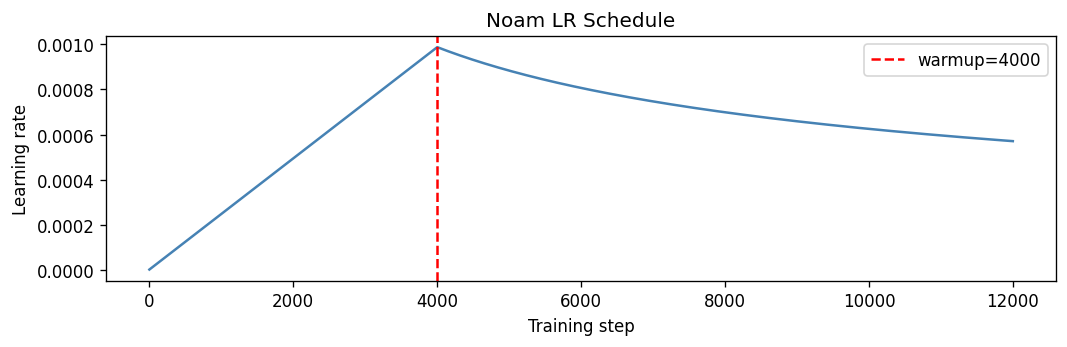

In [17]:
class NoamScheduler:
    """Warmup + inverse-sqrt LR schedule from Vaswani et al. 2017."""
    def __init__(self, optimizer, d_model, warmup_steps):
        self.opt     = optimizer
        self.d_model = d_model
        self.warmup  = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup ** -1.5))
        for pg in self.opt.param_groups:
            pg['lr'] = lr
        return lr

    def get_lr(self):
        return self.opt.param_groups[0]['lr']


class LabelSmoothingLoss(nn.Module):
    """
    Cross-entropy with label smoothing.
    Distributes epsilon probability mass uniformly across all classes.
    """
    def __init__(self, vocab_size, pad_idx, smoothing=LABEL_SMOOTH):
        super().__init__()
        self.pad_idx   = pad_idx
        self.smoothing = smoothing
        self.vocab_size = vocab_size
        self.confidence = 1.0 - smoothing

    def forward(self, logits, targets):
        # logits:  (N, V)  |  targets: (N,)
        V = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)            # (N, V)

        # Smooth target distribution
        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs,
                                              self.smoothing / (V - 2))
            smooth_targets.scatter_(1, targets.unsqueeze(1), self.confidence)
            smooth_targets[:, self.pad_idx] = 0.0
            mask = (targets == self.pad_idx)
            smooth_targets[mask] = 0.0

        loss = -(smooth_targets * log_probs).sum(dim=-1)
        return loss[~mask].mean()


optimizer = torch.optim.Adam(
    model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, D_MODEL, WARMUP)
criterion = LabelSmoothingLoss(
    len(tgt_vocab), pad_idx=tgt_vocab.w2i[PAD], smoothing=LABEL_SMOOTH)

# Visualise LR schedule
steps = range(1, max(N_EPOCHS * len(train_loader), WARMUP * 3))
_sched = NoamScheduler(
    torch.optim.Adam([torch.zeros(1)], lr=0), D_MODEL, WARMUP)
lrs = [_sched.step() for _ in steps]
plt.figure(figsize=(9, 3))
plt.plot(steps, lrs, color='steelblue')
plt.axvline(WARMUP, color='red', linestyle='--', label=f'warmup={WARMUP}')
plt.xlabel('Training step'); plt.ylabel('Learning rate')
plt.title('Noam LR Schedule'); plt.legend(); plt.tight_layout()
plt.savefig('/content/lr_schedule.png', dpi=120); plt.show()

## 10 · Training Loop

In [18]:
def train_epoch(model, loader, optimizer, scheduler, criterion, clip):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        # tgt_in  = tgt without last token  (<sos> ... last_word)
        # tgt_out = tgt without first token (first_word ... <eos>)
        tgt_in  = tgt[:, :-1]   # (B, T-1)
        tgt_out = tgt[:, 1:]    # (B, T-1)

        optimizer.zero_grad()
        logits, _, _ = model(src, tgt_in)       # (B, T-1, V)

        # Flatten for loss
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in  = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            logits, _, _ = model(src, tgt_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

In [19]:
history  = {'train': [], 'val': [], 'ppl': [], 'lr': []}
best_val = float('inf')

print(f'Training {N_EPOCHS} epochs on {DEVICE}...\n')
print(f'{"Epoch":>5} | {"Train":>8} | {"Val":>8} | {"PPL":>8} | {"LR":>10} | {"Time":>6}')
print('─' * 58)

for epoch in range(1, N_EPOCHS + 1):
    t0  = time.time()
    tr  = train_epoch(model, train_loader, optimizer, scheduler, criterion, CLIP)
    val = eval_epoch(model, val_loader, criterion)
    ppl = math.exp(min(val, 10))   # cap PPL display at e^10
    lr  = scheduler.get_lr()

    history['train'].append(tr)
    history['val'].append(val)
    history['ppl'].append(ppl)
    history['lr'].append(lr)

    tag = ' ←' if val < best_val else ''
    if val < best_val:
        best_val = val
        torch.save(model.state_dict(), CKPT_PATH)

    print(f'{epoch:>5} | {tr:>8.4f} | {val:>8.4f} | '
          f'{ppl:>8.2f} | {lr:>10.2e} | {time.time()-t0:>5.0f}s{tag}')

print(f'\n✅ Done — best val loss: {best_val:.4f}  PPL: {math.exp(min(best_val,10)):.2f}')

Training 30 epochs on cuda...

Epoch |    Train |      Val |      PPL |         LR |   Time
──────────────────────────────────────────────────────────
    1 |   7.9020 |   7.1569 |  1282.89 |   1.88e-05 |     5s ←
    2 |   7.0875 |   6.5664 |   710.78 |   3.76e-05 |     3s ←
    3 |   6.4384 |   5.6201 |   275.92 |   5.63e-05 |     3s ←
    4 |   5.6370 |   4.9951 |   147.69 |   7.51e-05 |     3s ←
    5 |   5.2379 |   4.7819 |   119.33 |   9.39e-05 |     4s ←
    6 |   5.0816 |   4.6763 |   107.38 |   1.13e-04 |     3s ←
    7 |   4.9622 |   4.5829 |    97.80 |   1.31e-04 |     3s ←
    8 |   4.8484 |   4.4778 |    88.04 |   1.50e-04 |     4s ←
    9 |   4.7245 |   4.3826 |    80.05 |   1.69e-04 |     3s ←
   10 |   4.5933 |   4.3443 |    77.04 |   1.88e-04 |     3s ←
   11 |   4.4640 |   4.1587 |    63.99 |   2.07e-04 |     3s ←
   12 |   4.3249 |   4.0784 |    59.05 |   2.25e-04 |     4s ←
   13 |   4.1878 |   4.0049 |    54.87 |   2.44e-04 |     3s ←
   14 |   4.0372 |   3.8798 | 

## 11 · Training Curves

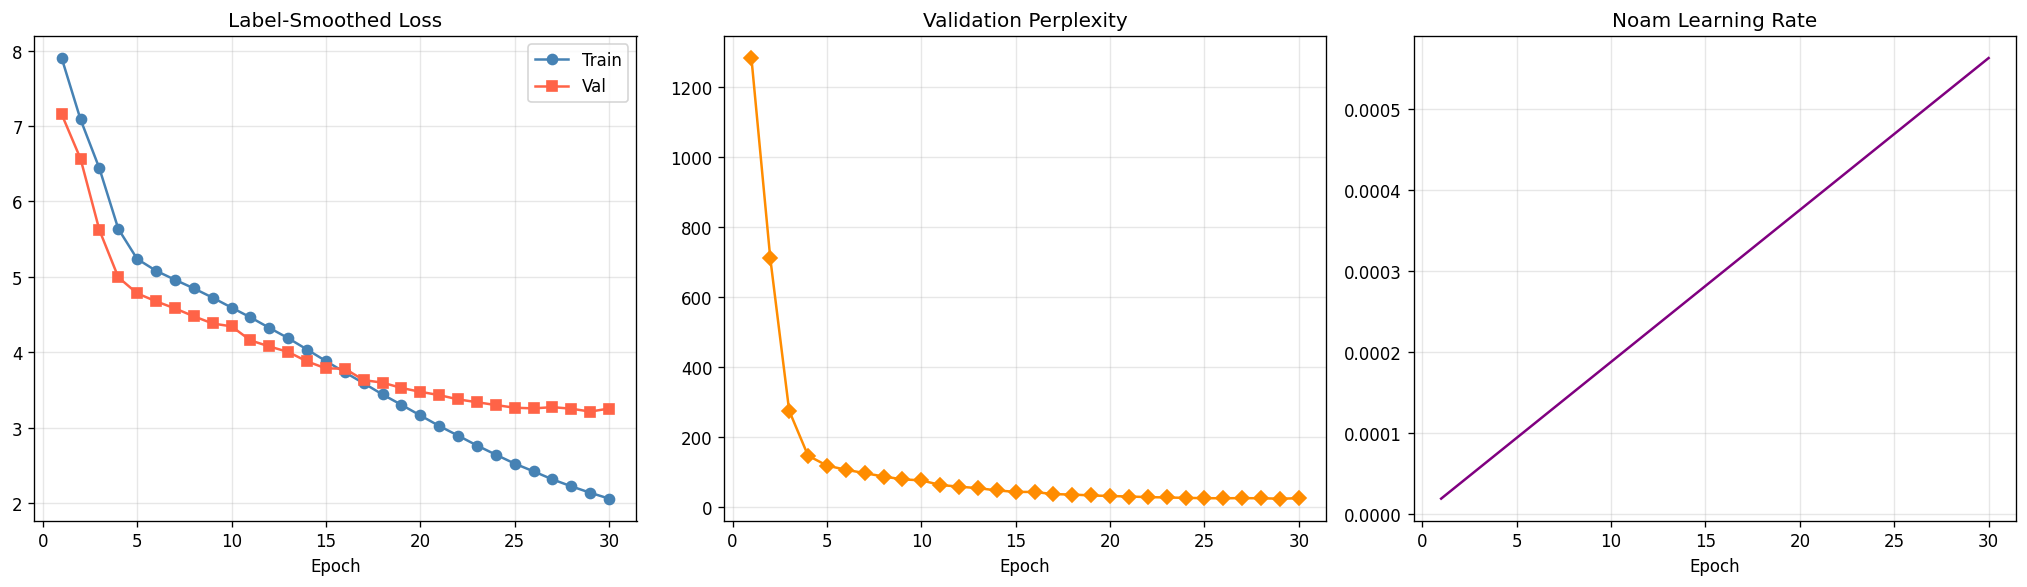

History saved.


In [20]:
epochs = range(1, len(history['train']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(epochs, history['train'], 'o-', color='steelblue', label='Train')
axes[0].plot(epochs, history['val'],   's-', color='tomato',    label='Val')
axes[0].set_title('Label-Smoothed Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['ppl'], 'D-', color='darkorange')
axes[1].set_title('Validation Perplexity'); axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)

axes[2].plot(range(1, len(history['lr'])+1), history['lr'], color='purple')
axes[2].set_title('Noam Learning Rate'); axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

with open('/content/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('History saved.')

## 12 · BLEU Evaluation

In [21]:
def corpus_bleu(hypotheses, references):
    """BLEU-4 with add-1 smoothing."""
    scores = []
    for hyp, ref in zip(hypotheses, references):
        if not hyp or not ref:
            scores.append(0.0); continue
        bp    = min(1.0, math.exp(1 - len(ref) / max(len(hyp), 1)))
        log_p = 0.0
        for n in range(1, 5):
            hng   = Counter(tuple(hyp[i:i+n]) for i in range(len(hyp)-n+1))
            rng   = Counter(tuple(ref[i:i+n]) for i in range(len(ref)-n+1))
            clip  = sum(min(c, rng[g]) for g, c in hng.items())
            total = max(len(hyp) - n + 1, 0)
            log_p += math.log((clip + 1) / (total + 1))
        scores.append(bp * math.exp(log_p / 4))
    return sum(scores) / len(scores) * 100 if scores else 0.0


# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
sos_idx = tgt_vocab.w2i[SOS]
eos_idx = tgt_vocab.w2i[EOS]

# ── Overall BLEU ──────────────────────────────────────────────────────────────
N_EVAL  = 400
sample  = random.sample(val_pairs, min(N_EVAL, len(val_pairs)))
hyps_g, hyps_b, refs = [], [], []

for en_tok, ar_tok in sample:
    src_ids = src_vocab.encode(en_tok) + [src_vocab.w2i[EOS]]
    src_t   = torch.tensor(src_ids, dtype=torch.long)
    g_ids, _ = model.translate_greedy(src_t, sos_idx, eos_idx)
    b_ids    = model.translate_beam(src_t, sos_idx, eos_idx, beam_width=5)
    hyps_g.append(tgt_vocab.decode(g_ids))
    hyps_b.append(tgt_vocab.decode(b_ids))
    refs.append(ar_tok)

bleu_g = corpus_bleu(hyps_g, refs)
bleu_b = corpus_bleu(hyps_b, refs)
print(f'BLEU-4  Greedy : {bleu_g:.2f}')
print(f'BLEU-4  Beam-5 : {bleu_b:.2f}')

# ── BLEU by source length ─────────────────────────────────────────────────────
print('\nBLEU-4 by source sentence length:')
print(f'{"Bucket":<16} {"n":>5}  {"Greedy":>8}  {"Beam-5":>8}')
print('─' * 44)
for lo, hi, lbl in [(1,3,'1-3 tok'),(4,6,'4-6 tok'),
                     (7,10,'7-10 tok'),(11,MAX_LEN,f'11+ tok')]:
    idxs = [i for i,(en,_) in enumerate(sample) if lo<=len(en)<=hi]
    if not idxs: continue
    g = corpus_bleu([hyps_g[i] for i in idxs], [refs[i] for i in idxs])
    b = corpus_bleu([hyps_b[i] for i in idxs], [refs[i] for i in idxs])
    print(f'{lbl:<16} {len(idxs):>5}  {g:>8.2f}  {b:>8.2f}')

BLEU-4  Greedy : 36.65
BLEU-4  Beam-5 : 37.44

BLEU-4 by source sentence length:
Bucket               n    Greedy    Beam-5
────────────────────────────────────────────
1-3 tok             10     53.93     63.15
4-6 tok            196     45.00     45.09
7-10 tok           168     28.12     29.15
11+ tok             26     22.19     23.51


## 13 · Cross-Attention Heatmaps

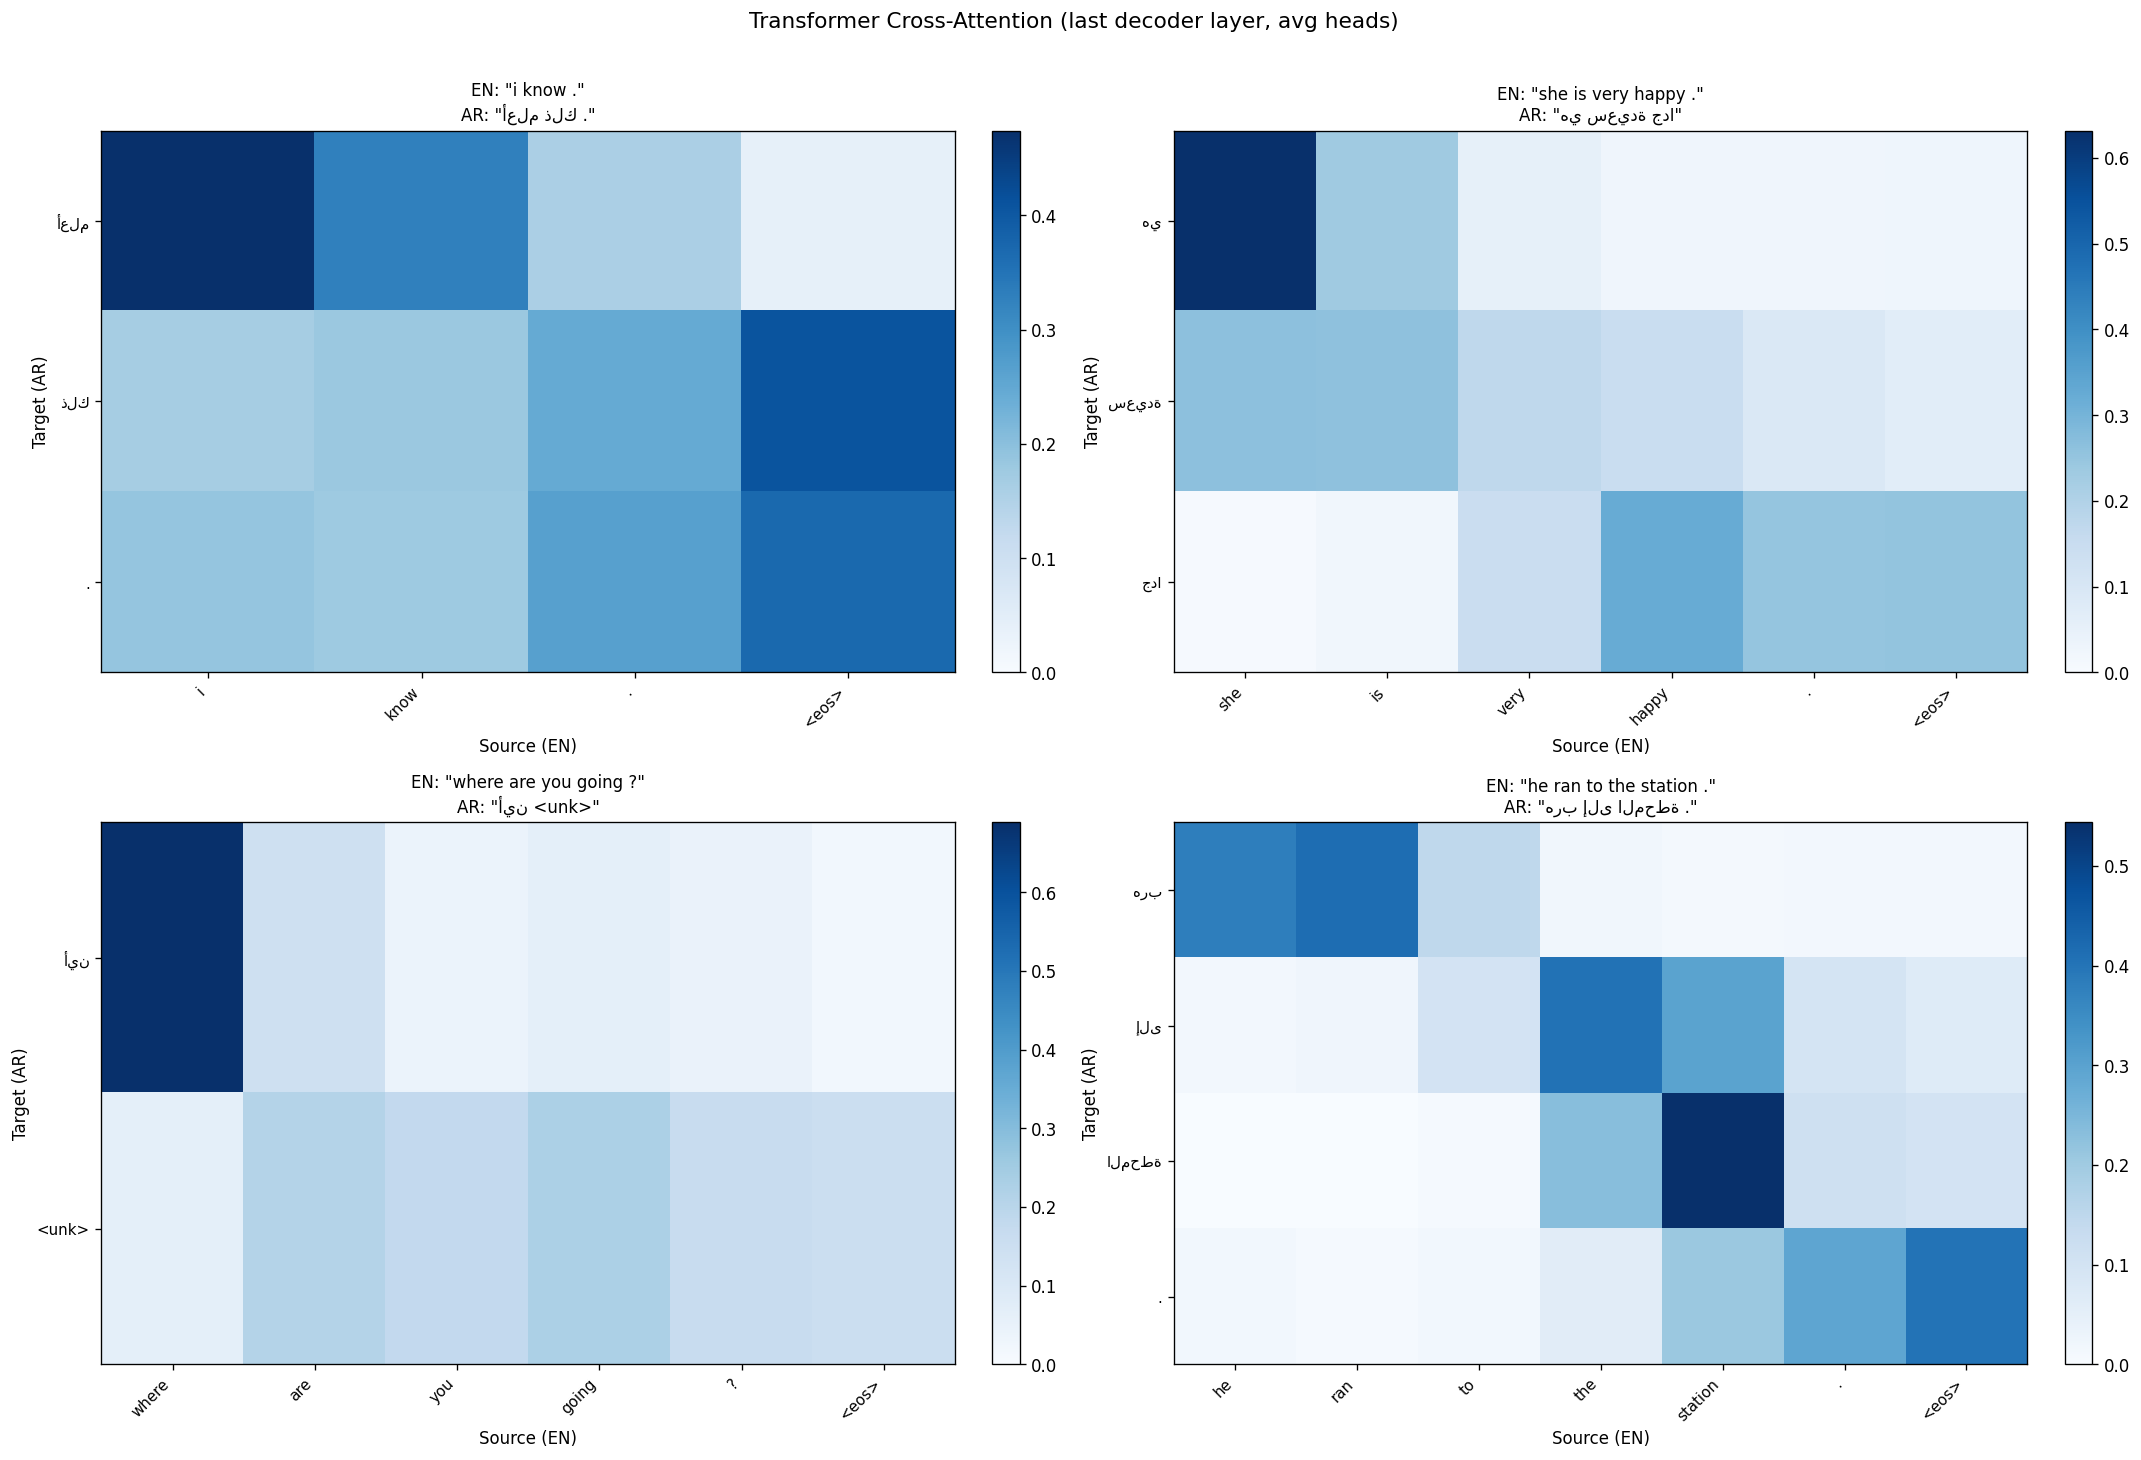

In [24]:
def plot_cross_attention(src_tokens, tgt_tokens, attn_matrix, title='', ax=None):
    """
    attn_matrix: (tgt_len, src_len) — averaged over heads, last decoder layer
    Rows = AR tokens produced  |  Cols = EN tokens attended over
    """
    if ax is None:
        fig, ax = plt.subplots(
            figsize=(max(6, len(src_tokens)), max(4, len(tgt_tokens))))
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(tgt_tokens, fontsize=9)
    ax.set_xlabel('Source (EN)'); ax.set_ylabel('Target (AR)')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def get_attn_data(sentence):
    en_tok  = tokenize_en(sentence)
    src_ids = src_vocab.encode(en_tok) + [src_vocab.w2i[EOS]]
    src_t   = torch.tensor(src_ids, dtype=torch.long)
    pred_ids, attn_map = model.translate_greedy(src_t, sos_idx, eos_idx)
    ar_tok  = tgt_vocab.decode(pred_ids)
    src_lbl = en_tok + ['<eos>']
    # attn_map: (tgt_len, src_len) — trim to actual lengths
    attn_map = attn_map[:len(ar_tok), :len(src_lbl)]
    return src_lbl, ar_tok, attn_map


demo_sents = [
    'i know .',
    'she is very happy .',
    'where are you going ?',
    'he ran to the station .',
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, sent in zip(axes.flatten(), demo_sents):
    src_lbl, tgt_lbl, attn = get_attn_data(sent)
    if not tgt_lbl:
        ax.set_visible(False); continue
    plot_cross_attention(
        src_lbl, tgt_lbl, attn,
        title=f'EN: "{sent}"\nAR: "{" ".join(tgt_lbl)}"', ax=ax)

plt.suptitle('Transformer Cross-Attention (last decoder layer, avg heads)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 14 · Per-Head Attention (one sentence)

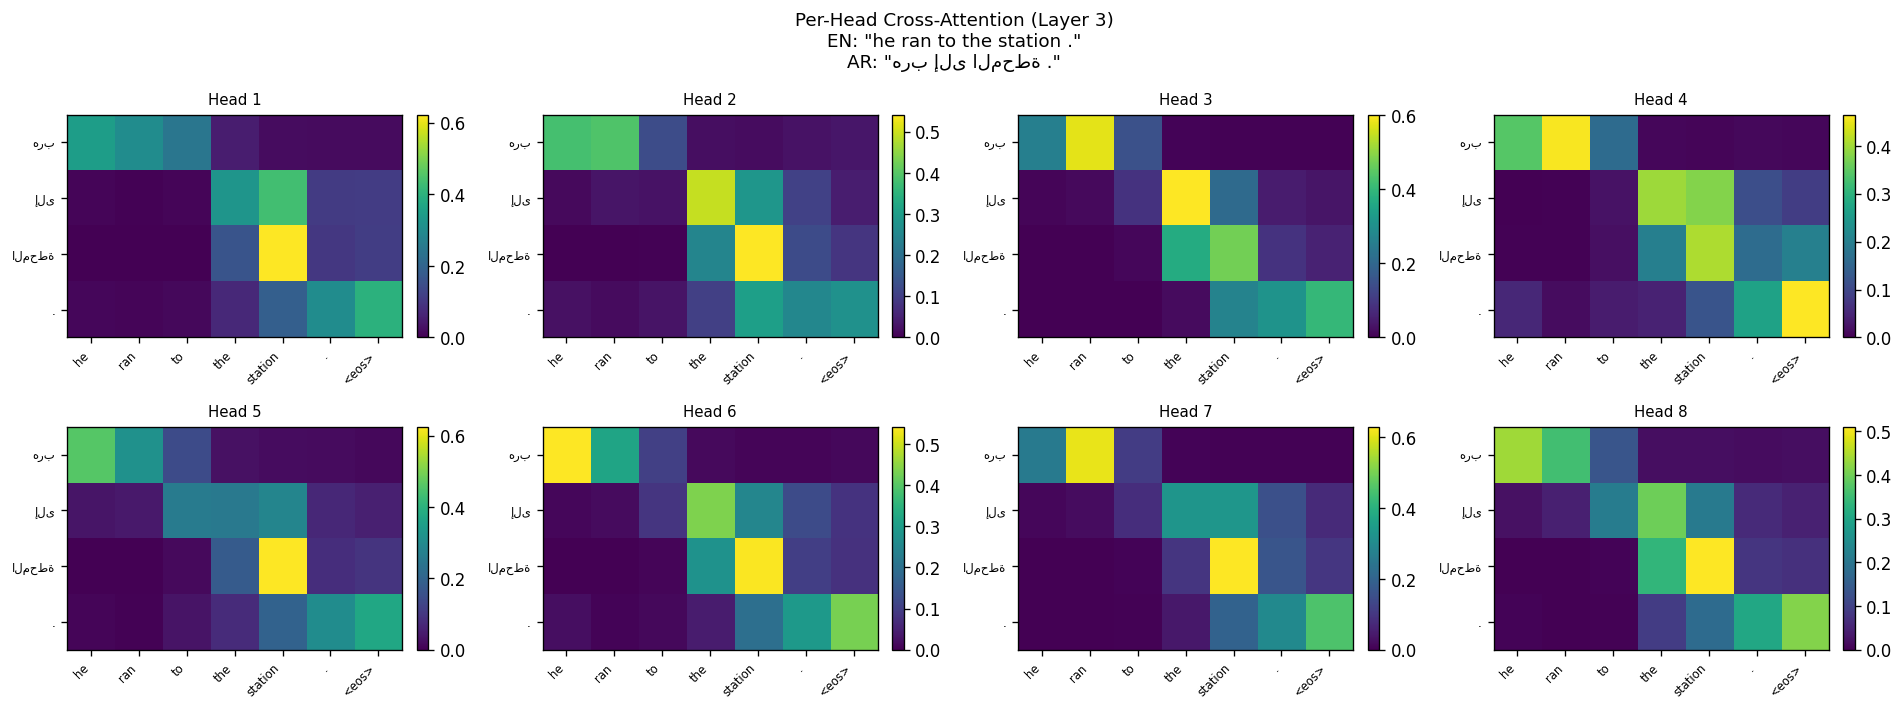

In [25]:
def plot_per_head_attention(sentence, layer_idx=-1):
    """
    Show each attention head separately for the given sentence.
    layer_idx: which decoder layer to visualise (-1 = last).
    """
    en_tok  = tokenize_en(sentence)
    src_ids = src_vocab.encode(en_tok) + [src_vocab.w2i[EOS]]
    src_t   = torch.tensor(src_ids, dtype=torch.long)
    src     = src_t.unsqueeze(0).to(DEVICE)
    src_lbl = en_tok + ['<eos>']

    model.eval()
    with torch.no_grad():
        src_mask = model.make_src_mask(src).to(DEVICE)
        memory, _ = model.encoder(src, src_mask)

        # Do greedy decoding to get target tokens
        tgt = torch.tensor([[sos_idx]], device=DEVICE)
        for _ in range(60):
            tgt_mask = model.make_tgt_mask(tgt).to(DEVICE)
            out, _, cross_attn = model.decoder(tgt, memory, tgt_mask, src_mask)
            next_tok = model.fc_out(out[:, -1, :]).argmax(-1)
            if next_tok.item() == eos_idx: break
            tgt = torch.cat([tgt, next_tok.unsqueeze(0)], dim=1)

    tgt_ids = tgt[0, 1:].tolist()
    tgt_lbl = tgt_vocab.decode(tgt_ids)

    # cross_attn[layer_idx]: (1, H, tgt_len, src_len)
    attn_all_heads = cross_attn[layer_idx][0].cpu().numpy()  # (H, tgt_len, src_len)
    H = attn_all_heads.shape[0]

    cols = 4; rows = math.ceil(H / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    axes = axes.flatten()

    for h in range(H):
        attn_h = attn_all_heads[h, :len(tgt_lbl), :len(src_lbl)]
        im = axes[h].imshow(attn_h, cmap='viridis', aspect='auto', vmin=0)
        axes[h].set_xticks(range(len(src_lbl)))
        axes[h].set_xticklabels(src_lbl, rotation=45, ha='right', fontsize=7)
        axes[h].set_yticks(range(len(tgt_lbl)))
        axes[h].set_yticklabels(tgt_lbl, fontsize=7)
        axes[h].set_title(f'Head {h+1}', fontsize=9)
        plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.04)

    for h in range(H, len(axes)):
        axes[h].set_visible(False)

    layer_str = f'Layer {len(model.decoder.layers) + layer_idx + 1}' if layer_idx < 0 else f'Layer {layer_idx+1}'
    plt.suptitle(f'Per-Head Cross-Attention ({layer_str})\nEN: "{sentence}"\nAR: "{" ".join(tgt_lbl)}"',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('/content/per_head_attention.png', dpi=130, bbox_inches='tight')
    plt.show()


plot_per_head_attention('he ran to the station .')

## 15 · Interactive Translation Demo

In [26]:
def translate(sentence: str, beam_width: int = 5,
              length_penalty: float = 0.6, show_attention: bool = True):
    en_tok  = tokenize_en(sentence)
    src_ids = src_vocab.encode(en_tok) + [src_vocab.w2i[EOS]]
    src_t   = torch.tensor(src_ids, dtype=torch.long)

    g_ids, attn = model.translate_greedy(src_t, sos_idx, eos_idx)
    b_ids       = model.translate_beam(
        src_t, sos_idx, eos_idx, beam_width, length_penalty=length_penalty)

    print(f'Input    (EN) : {sentence}')
    print(f'Greedy   (AR) : {" ".join(tgt_vocab.decode(g_ids))}')
    print(f'Beam-{beam_width}  (AR) : {" ".join(tgt_vocab.decode(b_ids))}')

    if show_attention and g_ids:
        src_lbl = en_tok + ['<eos>']
        tgt_lbl = tgt_vocab.decode(g_ids)
        attn_m  = attn[:len(tgt_lbl), :len(src_lbl)]
        fig, ax = plt.subplots(
            figsize=(max(6, len(src_lbl)+1), max(4, len(tgt_lbl)+1)))
        plot_cross_attention(
            src_lbl, tgt_lbl, attn_m,
            title=f'Cross-attention: "{sentence}"', ax=ax)
        plt.tight_layout(); plt.show()

    return ' '.join(tgt_vocab.decode(b_ids))


# ── Try your own sentences ─────────────────────────────────────────────────
test_sentences = [
    'i love you .',
    'hello , how are you ?',
    'the book is on the table .',
    'she does not know him .',
    'stop !',
    'run !',
]

for s in test_sentences:
    print('─' * 55)
    translate(s, show_attention=False)
print('─' * 55)

───────────────────────────────────────────────────────
Input    (EN) : i love you .
Greedy   (AR) : أحبك .
Beam-5  (AR) : أحبك .
───────────────────────────────────────────────────────
Input    (EN) : hello , how are you ?
Greedy   (AR) : مرحباً ، يا <unk>
Beam-5  (AR) : مرحباً , يا <unk>
───────────────────────────────────────────────────────
Input    (EN) : the book is on the table .
Greedy   (AR) : الكتاب على الطاولة .
Beam-5  (AR) : الكتاب على الطاولة .
───────────────────────────────────────────────────────
Input    (EN) : she does not know him .
Greedy   (AR) : إنها لا تعرف .
Beam-5  (AR) : إنها لا تعرف .
───────────────────────────────────────────────────────
Input    (EN) : stop !
Greedy   (AR) : أوقف الصراخ !
Beam-5  (AR) : قف !
───────────────────────────────────────────────────────
Input    (EN) : run !
Greedy   (AR) : <unk> !
Beam-5  (AR) : <unk> !
───────────────────────────────────────────────────────


Input    (EN) : where are you going ?
Greedy   (AR) : أين <unk>
Beam-5  (AR) : أين <unk>


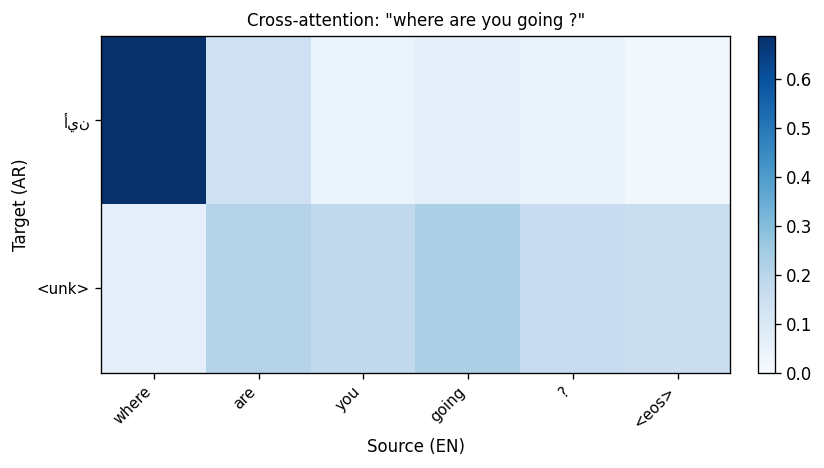

'أين <unk>'

In [27]:
# ── Single sentence with attention heatmap ────────────────────────────────────
translate('where are you going ?', beam_width=5, show_attention=True)

## 16 · Best & Worst Translations

In [28]:
def sentence_bleu(hyp, ref):
    return corpus_bleu([hyp], [ref]) if hyp and ref else 0.0

scored = []
for en_tok, ar_tok in random.sample(val_pairs, min(300, len(val_pairs))):
    src_ids  = src_vocab.encode(en_tok) + [src_vocab.w2i[EOS]]
    src_t    = torch.tensor(src_ids, dtype=torch.long)
    b_ids    = model.translate_beam(src_t, sos_idx, eos_idx, beam_width=5)
    pred_tok = tgt_vocab.decode(b_ids)
    scored.append((sentence_bleu(pred_tok, ar_tok), en_tok, ar_tok, pred_tok))

scored.sort(key=lambda x: x[0])

print('10 WORST translations:\n')
for bleu_s, en, ref, pred in scored[:10]:
    print(f'  BLEU {bleu_s:.2f} | EN: {" ".join(en)}')
    print(f' Ref : {" ".join(ref)}')
    print(f' Pred: {" ".join(pred)}\n')

print('\n10 BEST translations:\n')
for bleu_s, en, ref, pred in scored[-10:][::-1]:
    print(f'  BLEU {bleu_s:.2f} | EN: {" ".join(en)}')
    print(f' Ref : {" ".join(ref)}')
    print(f' Pred: {" ".join(pred)}\n')

10 WORST translations:

  BLEU 7.04 | EN: i studied in boston from 2003 to 2007 .
          Ref : درست في بوسطون من عام ألفين و ثلاثة إلى عام ألفين و سبعة للميلاد .
          Pred: <unk> من بوسطن <unk> إلى <unk> .

  BLEU 8.15 | EN: you probably think you know how to do this , but let me explain it once more .
          Ref : ربما كنت تعتقد أنك تعرف كيفية القيام بذلك ، ولكن اسمح لي أن أشرح مرة أخرى .
          Pred: على تظن أن كل ما <unk> ، <unk> لك ما تفعله .

  BLEU 10.02 | EN: there are no shortcuts to the top , only to the bottom .
          Ref : لا يوجد طرق مختصرة إلى القمة . تلك الطرق تؤدي إلى الهاوية .
          Pred: ليس هناك <unk> على <unk> فقط إلى <unk> .

  BLEU 10.32 | EN: i remember the event as clearly as if it had happened just yesterday .
          Ref : أتذكر الحادثة بكل وضوح وكأنها حدثت البارحة فقط .
          Pred: أذكر أني كنتُ في مكاني؟

  BLEU 12.20 | EN: would you rather be fat and ugly or thin and sexy ?
          Ref : هل تفضل أن تكون بدين وقبيح أو أن تكون نحي

## 17 · Save Checkpoint & Download

In [29]:
FULL_CKPT = '/content/transformer_nmt_full.pt'
torch.save({
    'model_state': model.state_dict(),
    'src_vocab':   src_vocab,
    'tgt_vocab':   tgt_vocab,
    'history':     history,
    'config': dict(
        MAX_LEN=MAX_LEN, D_MODEL=D_MODEL, N_HEADS=N_HEADS,
        N_LAYERS=N_LAYERS, D_FF=D_FF, DROPOUT=DROPOUT,
    )
}, FULL_CKPT)
print(f'Checkpoint saved → {FULL_CKPT}')

# ── Download everything ────────────────────────────────────────────────────
from google.colab import files
for f_path in [FULL_CKPT,
               '/content/training_curves.png',
               '/content/attention_heatmaps.png',
               '/content/per_head_attention.png',
               '/content/lr_schedule.png',
               '/content/training_history.json']:
    try:
        files.download(f_path)
    except Exception as e:
        print(f'Could not download {f_path}: {e}')
print('✅ All files downloaded.')

Checkpoint saved → /content/transformer_nmt_full.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded.


---
## Architecture Summary

| Component | Formula / Detail |
|---|---|
| **Positional Encoding** | `PE(pos,2i) = sin(pos/10000^(2i/d))` |
| **Multi-Head Attention** | `Attn(Q,K,V) = softmax(QKᵀ/√d_k)·V` — h parallel heads |
| **Encoder Layer** | Self-Attn → Add&Norm → FFN → Add&Norm |
| **Decoder Layer** | Masked Self-Attn → Add&Norm → **Cross-Attn** → Add&Norm → FFN → Add&Norm |
| **Masks** | PAD mask (encoder) + Causal triangular mask (decoder) |
| **Loss** | Cross-entropy with label smoothing (ε=0.1) |
| **Optimizer** | Adam (β₁=0.9, β₂=0.98, ε=1e-9) |
| **LR Schedule** | Noam warmup then inverse-sqrt decay |
| **Decoding** | Greedy argmax + Beam search with length penalty |

### Transformer vs RNN-Attention (previous notebook)

| | RNN + Bahdanau | Transformer |
|---|---|---|
| Context | Sequential hidden states | All positions in parallel |
| Alignment | Additive (one head) | Multi-head dot-product |
| Long-range deps | Degrades with distance | Constant via direct attention |
| Training speed | Slow (sequential) | Fast (parallelisable) |
| Positional info | Implicit in RNN order | Explicit via sinusoidal PE |
| BLEU (same data) | Baseline | Typically +5–15 BLEU |

### Next improvements
- **SentencePiece / BPE** subword tokenisation (critical for Arabic morphology)
- **Pre-trained embeddings** (AraVec for Arabic)
- **Larger model**: `D_MODEL=512, N_HEADS=8, N_LAYERS=6` (original paper)
- **Data augmentation**: OPUS EN-AR corpus (millions of pairs)
- **Fine-tune mBART or Helsinki-NLP/opus-mt-en-ar** instead of training from scratch